<a href="https://colab.research.google.com/github/SURYA-ADS-eng/ALGONIVE_surya/blob/main/surya_algonive_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#TASK 1- FIRST, IMPORT THE MODULES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
#LOAD THE DATASET

df=pd.read_excel("/content/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
#VIEWING THE COLUMNS AND DATATYPES (understand the data)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
#DESCRIBE THE DATASET AS COUNT,MIN,MAX,MEAN,STD,25%,50%,75% (understand the data)

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
#CHECH MISSING VALUES (data cleaning)


df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [6]:
#HANDLING THE MISSING VALUES (data cleaning)


df = df.dropna(subset=['CustomerID'])

In [7]:
#RECHECK THE NULL VALUES (data cleaning)

df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

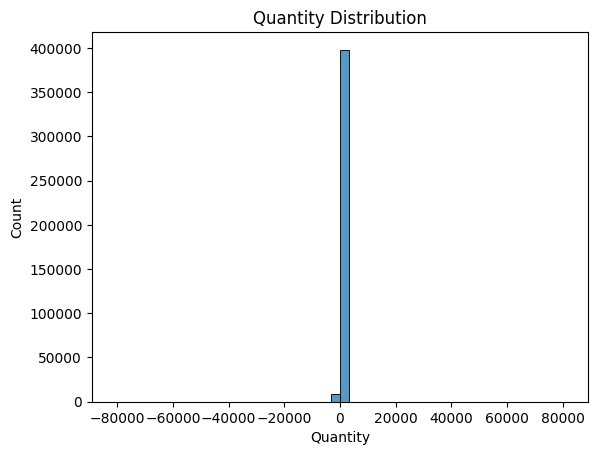

In [9]:
#QUANTITY DISTRIBUTION (EDA)

sns.histplot(df['Quantity'],bins=50)
plt.title("Quantity Distribution")
plt.show()

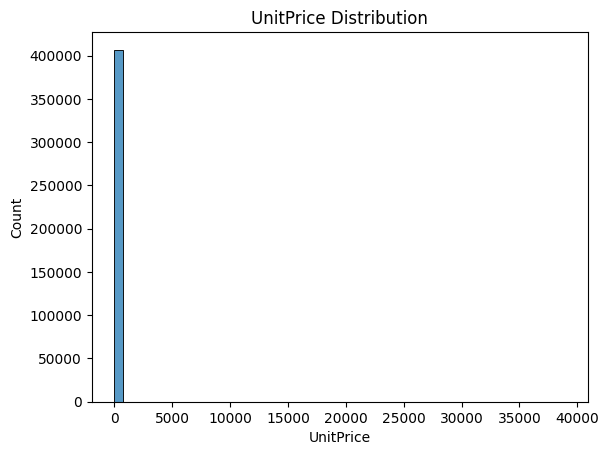

In [10]:
#UNITPRICE DISTRIBUTION (EDA)

sns.histplot(df['UnitPrice'],bins=50)
plt.title("UnitPrice Distribution")
plt.show()

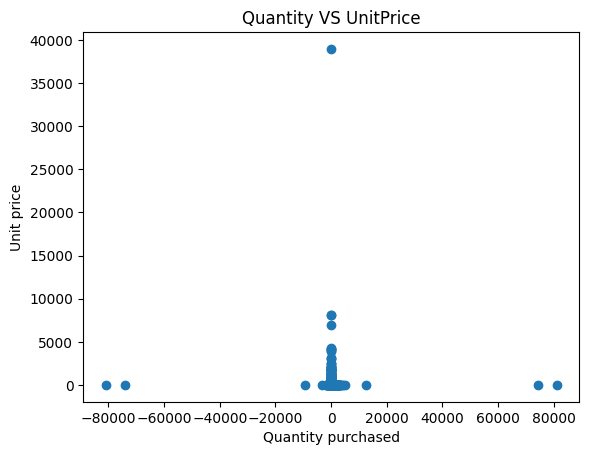

In [11]:
#QUANTITY VS UUNITPRICE (EDA)

plt.scatter(df["Quantity"],df["UnitPrice"])
plt.xlabel("Quantity purchased")
plt.ylabel("Unit price")
plt.title("Quantity VS UnitPrice")
plt.show()

In [12]:
#TOTAL PRICE (FEATURE ENGINEERING)

df["Total Price"]=df["Quantity"]*df["UnitPrice"]
print(df["Total Price"])

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: Total Price, Length: 406829, dtype: float64


In [13]:
#CUSTOMER-LEVEL FEATURES (FEATURE ENGINEERING)

customer_data=df.groupby("CustomerID").agg({"Quantity": "sum","Total Price": "sum","InvoiceNo": "count"})
print(customer_data)

            Quantity  Total Price  InvoiceNo
CustomerID                                  
12346.0            0         0.00          2
12347.0         2458      4310.00        182
12348.0         2341      1797.24         31
12349.0          631      1757.55         73
12350.0          197       334.40         17
...              ...          ...        ...
18280.0           45       180.60         10
18281.0           54        80.82          7
18282.0           98       176.60         13
18283.0         1397      2094.88        756
18287.0         1586      1837.28         70

[4372 rows x 3 columns]


In [17]:
#RENAME THE COLUMNS (FEATURE ENGINEERING)

customer_data.columns=["TotalQuantity","TotalSpending","TotalTransactions"]
customer_data.head()

,TotalQuantity,TotalSpending,TotalTransactions
CustomerID,,,
12346.0,0,0.00,2
12347.0,2458,4310.00,182
12348.0,2341,1797.24,31
12349.0,631,1757.55,73
12350.0,197,334.40,17


In [18]:
#CLUSTERING (FEATURE SELECTION)

x=customer_data[["TotalQuantity","TotalSpending","TotalTransactions"]]

In [23]:
#DATA SCLING (CLUSTRING ACCURACY)

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

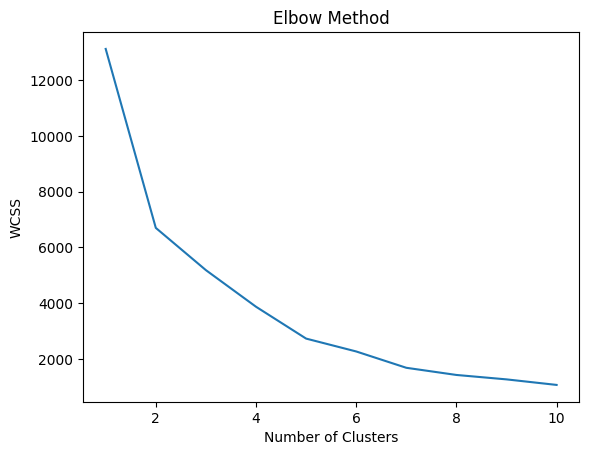

In [26]:
# BEST NO.OF CLUSTERS (ELBOW METHOD)

from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,random_state=42)
  kmeans.fit(x_scaled)
  wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [28]:
#K-MEANS CLUSTERING

kmeans=KMeans(n_clusters=5,random_state=42)
customer_data["Cluster"]=kmeans.fit_predict(x_scaled)
customer_data.head()

,TotalQuantity,TotalSpending,TotalTransactions,Cluster
CustomerID,,,,
12346.0,0,0.00,2,0
12347.0,2458,4310.00,182,0
12348.0,2341,1797.24,31,0
12349.0,631,1757.55,73,0
12350.0,197,334.40,17,0


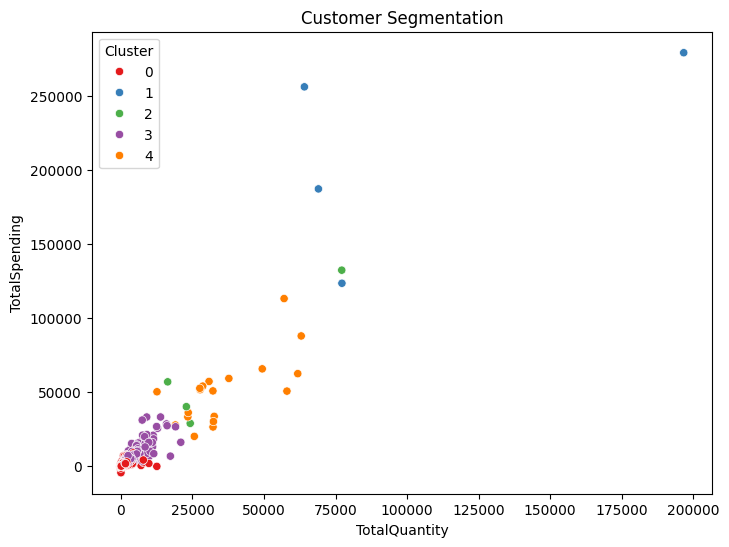

In [29]:
#SPENDING VS QUANTITY

plt.figure(figsize=(8,6))
sns.scatterplot(x=customer_data["TotalQuantity"],y=customer_data["TotalSpending"],hue=customer_data["Cluster"],palette="Set1")
plt.title("Customer Segmentation")
plt.show()